📊 Performance Comparison:

IDW:
  MAE  = 48.237
  RMSE = 93.763
  R²   = 0.821

Kriging:
  MAE  = 106.551
  RMSE = 150.721
  R²   = 0.537

🔁 Leave-One-Out CV (IDW):
  MAE  = 48.237
  RMSE = 93.763
  R²   = 0.821

🔁 Leave-One-Out CV (Kriging):
  MAE  = 106.551
  RMSE = 150.721
  R²   = 0.537


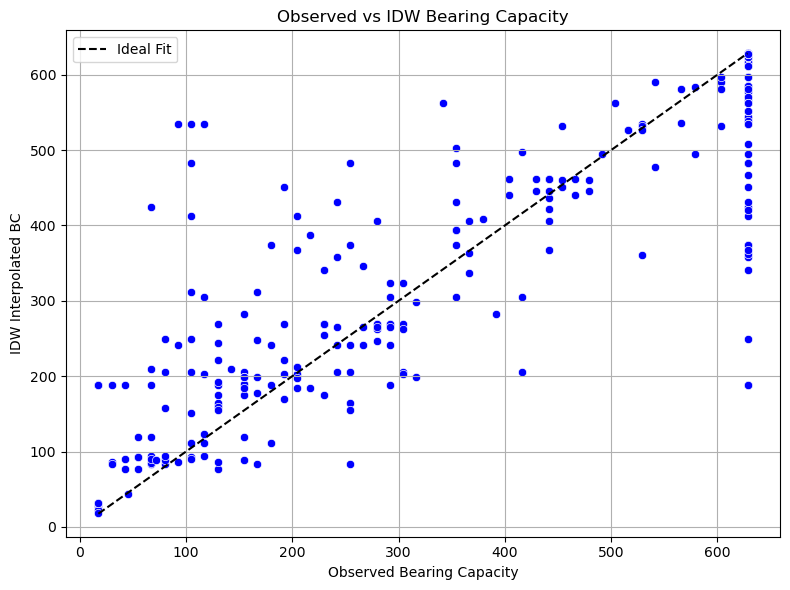

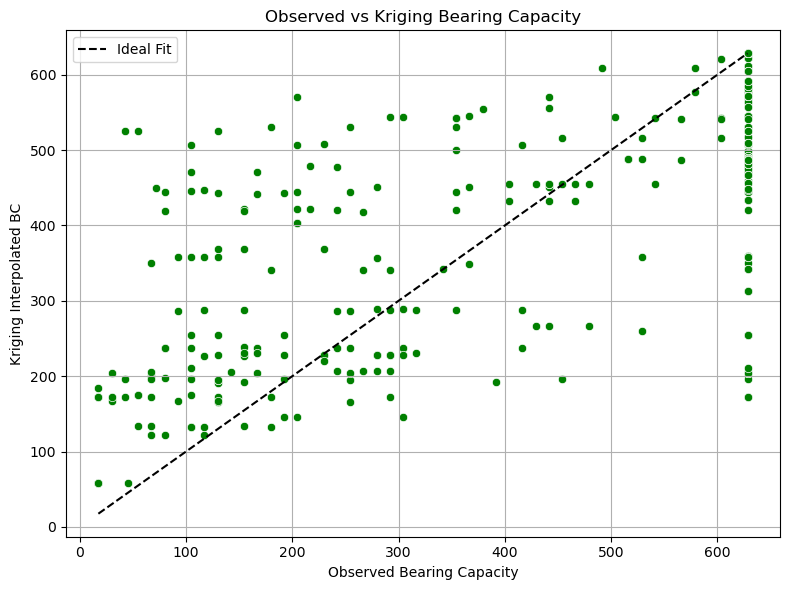

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load datasets
observed = pd.read_csv("observed.csv")  # Sparse ground truth points
idw = pd.read_csv("idw.csv")            # IDW interpolated data
ok = pd.read_csv("ok.csv")              # Kriging interpolated data

# Step 3: Function to find nearest interpolated 'bc' value for each observed point
def get_nearest_bc(observed_df, interp_df):
    nbrs = NearestNeighbors(n_neighbors=1).fit(interp_df[['x', 'y']])
    distances, indices = nbrs.kneighbors(observed_df[['x', 'y']])
    nearest_bc = interp_df.iloc[indices.flatten()]['bc'].values
    return nearest_bc

# Step 4: Attach nearest interpolated values to observed data
observed['bc_idw'] = get_nearest_bc(observed, idw)
observed['bc_ok'] = get_nearest_bc(observed, ok)

# Step 5: Function to calculate performance metrics
def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return mae, rmse, r2

# Step 6: Calculate and print performance metrics for IDW and Kriging
mae_idw, rmse_idw, r2_idw = evaluate(observed['bc'], observed['bc_idw'])
mae_ok, rmse_ok, r2_ok = evaluate(observed['bc'], observed['bc_ok'])

print("📊 Performance Comparison:")
print("\nIDW:")
print(f"  MAE  = {mae_idw:.3f}")
print(f"  RMSE = {rmse_idw:.3f}")
print(f"  R²   = {r2_idw:.3f}")

print("\nKriging:")
print(f"  MAE  = {mae_ok:.3f}")
print(f"  RMSE = {rmse_ok:.3f}")
print(f"  R²   = {r2_ok:.3f}")

# Step 7: Leave-One-Out Cross Validation (LOO-CV) function with fix
def loo_cross_validate(obs_df, interp_df, method_name="Method"):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    interp_nbrs = NearestNeighbors(n_neighbors=1).fit(interp_df[['x', 'y']])

    for train_index, test_index in loo.split(obs_df):
        # Extract 2D DataFrame for kneighbors input (fix warning)
        test_point = obs_df.iloc[test_index[0]][['x', 'y']].to_frame().T
        true_val = obs_df.iloc[test_index[0]]['bc']

        dist, idx = interp_nbrs.kneighbors(test_point)
        predicted_val = interp_df.iloc[idx[0][0]]['bc']

        y_true.append(true_val)
        y_pred.append(predicted_val)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n🔁 Leave-One-Out CV ({method_name}):")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R²   = {r2:.3f}")

# Step 8: Perform LOO-CV for both methods
loo_cross_validate(observed, idw, method_name="IDW")
loo_cross_validate(observed, ok, method_name="Kriging")

# Step 9: Plot Observed vs IDW
plt.figure(figsize=(8,6))
sns.scatterplot(x=observed['bc'], y=observed['bc_idw'], color='blue')
plt.plot([observed['bc'].min(), observed['bc'].max()],
         [observed['bc'].min(), observed['bc'].max()],
         'k--', label='Ideal Fit')
plt.xlabel("Observed Bearing Capacity")
plt.ylabel("IDW Interpolated BC")
plt.title("Observed vs IDW Bearing Capacity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 10: Plot Observed vs Kriging
plt.figure(figsize=(8,6))
sns.scatterplot(x=observed['bc'], y=observed['bc_ok'], color='green')
plt.plot([observed['bc'].min(), observed['bc'].max()],
         [observed['bc'].min(), observed['bc'].max()],
         'k--', label='Ideal Fit')
plt.xlabel("Observed Bearing Capacity")
plt.ylabel("Kriging Interpolated BC")
plt.title("Observed vs Kriging Bearing Capacity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
